# SFT Inference Testing

COntains functionality to test the models capability to work on SFT data and queries

**Model Paired BAses**: `/capstor/store/cscs/swissai/infra01/vision-ckpts/llama3-3b-15n-8192sl-120gbsz-0.9i-0.1t-paired-0022700/HF`

**Tokenizer**: `/capstor/store/cscs/swissai/infra01/MLLM/llama3_vision_instruct_emu3_tokenizer`

## 1. Setup and Imports

In [1]:
# Auto-reload modules
%load_ext autoreload
%autoreload 2

import sys
import os
import pathlib
import torch
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import gc

# Add project path
current_project_path = pathlib.Path(os.getcwd()).parent.parent
sys.path.append(str(current_project_path))
print(f"Project path added to system path: {current_project_path}")

# Check GPU availability
print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")

if torch.cuda.is_available():
    print(f"\nNumber of GPUs: {torch.cuda.device_count()}")
    for i in range(torch.cuda.device_count()):
        props = torch.cuda.get_device_properties(i)
        free, total = torch.cuda.mem_get_info(i)
        print(f"  GPU {i} ({props.name}):")
        print(f"    Total: {total/1024**3:.1f}GB, Free: {free/1024**3:.1f}GB")

Project path added to system path: /iopsstor/scratch/cscs/rkreft/benchmark-image-tokenizer
PyTorch version: 2.7.0a0+ecf3bae40a.nv25.02
CUDA available: True

Number of GPUs: 4
  GPU 0 (NVIDIA GH200 120GB):
    Total: 94.5GB, Free: 92.7GB
  GPU 1 (NVIDIA GH200 120GB):
    Total: 94.5GB, Free: 92.7GB
  GPU 2 (NVIDIA GH200 120GB):
    Total: 94.5GB, Free: 92.7GB
  GPU 3 (NVIDIA GH200 120GB):
    Total: 94.5GB, Free: 92.8GB


## 2. Initialize EMU3 Inferencer

In [41]:
# Clean up any existing processes and set environment
import os
import gc
import torch

# Set environment variables to prevent OOM and process issues
os.environ['PYTORCH_CUDA_ALLOC_CONF'] = 'expandable_segments:True'
os.environ['VLLM_WORKER_MULTIPROC_METHOD'] = 'spawn'
os.environ['CUDA_VISIBLE_DEVICES'] = '0'  # Use only GPU 0 for the LLM

# Clean up CUDA cache
if torch.cuda.is_available():
    torch.cuda.empty_cache()
    torch.cuda.synchronize()

# Force garbage collection
gc.collect()

print("Environment configured:")
print(f"  CUDA devices: {os.environ.get('CUDA_VISIBLE_DEVICES', 'all')}")
print(f"  Memory allocation: expandable segments enabled")
print(f"  Multiprocess method: spawn")

# Check current GPU status
if torch.cuda.is_available():
    for i in range(torch.cuda.device_count()):
        free, total = torch.cuda.mem_get_info(i)
        print(f"  GPU {i}: {free/1024**3:.1f}GB free / {total/1024**3:.1f}GB total")

Environment configured:
  CUDA devices: 0
  Memory allocation: expandable segments enabled
  Multiprocess method: spawn
  GPU 0: 11.7GB free / 94.5GB total
  GPU 1: 90.2GB free / 94.5GB total
  GPU 2: 92.4GB free / 94.5GB total
  GPU 3: 92.4GB free / 94.5GB total


## 1.5 Environment Setup

In [3]:
from emu3_vllm_inferencer import EMU3Inferencer

#MODEL = "/capstor/store/cscs/swissai/infra01/vision-ckpts/llama3-3b-15n-8192sl-120gbsz-0.9i-0.1t-paired-0022700/HF"
#MODEL ="/iopsstor/scratch/cscs/rkreft/Megatron-LM/logs/Meg-Runs/image-extension/llama3-3b-SFT-15n-8192sl-240gbsz-1.0i-0.0t-stage2-base-ST-MASKED-USR-MASKED-FIX/HF"
MODEL ="/iopsstor/scratch/cscs/rkreft/Megatron-LM/logs/Meg-Runs/image-extension/llama3-3b-SFT-15n-8192sl-240gbsz-1.0i-0.0t-stage2-base-ST-MASKED-USR-MASKED-NOTIMG-FIXES-RPAD/HF"
#MODEL ="/iopsstor/scratch/cscs/rkreft/Megatron-LM/logs/Meg-Runs/image-extension/llama3-3b-SFT-15n-8192sl-240gbsz-1.0i-0.0t-paired-base-ST-MASKED/HF" # no fix, usr masked, img masked
#MODEL ="/iopsstor/scratch/cscs/rkreft/Megatron-LM/logs/Meg-Runs/image-extension/llama3-3b-SFT-15n-8192sl-240gbsz-1.0i-0.0t-stage1-base-ST-MASKED-USR-MASKED/HF" # no fix, no paired train, usr masked, img masked

TOKENIZER = "/capstor/store/cscs/swissai/infra01/MLLM/llama3_vision_instruct_emu3_tokenizer"

# Initialize inferencer with 3B model on single GPU
inferencer = EMU3Inferencer(
    model_path=MODEL,
    tokenizer_path=TOKENIZER,
    tensor_parallel_size=1,  # 3B model fits on 1 GPU
    max_model_len=8192
)

print("\n✅ Inferencer initialized")
print("\nSpecial token IDs:")
for name, token_id in inferencer.special_token_ids.items():
    token = inferencer.tokenizer.decode([token_id])
    print(f"  {name:20s}: {token_id:6d} -> {token}")

print(f"\nVision mapping loaded: {len(inferencer.vision_mapping)} visual tokens")

/usr/local/lib/python3.12/dist-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


INFO 10-15 12:20:02 [__init__.py:239] Automatically detected platform cuda.


2025-10-15 12:20:06,819	INFO util.py:154 -- Missing packages: ['ipywidgets']. Run `pip install -U ipywidgets`, then restart the notebook server for rich notebook output.


Loading tokenizer from /capstor/store/cscs/swissai/infra01/MLLM/llama3_vision_instruct_emu3_tokenizer
Loading model from /iopsstor/scratch/cscs/rkreft/Megatron-LM/logs/Meg-Runs/image-extension/llama3-3b-SFT-15n-8192sl-240gbsz-1.0i-0.0t-stage2-base-ST-MASKED-USR-MASKED-NOTIMG-FIXES-RPAD/HF
Using 1 GPUs for tensor parallelism
INFO 10-15 12:20:29 [config.py:717] This model supports multiple tasks: {'score', 'embed', 'classify', 'generate', 'reward'}. Defaulting to 'generate'.
INFO 10-15 12:20:29 [config.py:2003] Chunked prefill is enabled with max_num_batched_tokens=16384.
INFO 10-15 12:20:48 [__init__.py:239] Automatically detected platform cuda.
INFO 10-15 12:20:50 [core.py:58] Initializing a V1 LLM engine (v0.8.6.dev0+g89bf9075d.d20250510) with config: model='/iopsstor/scratch/cscs/rkreft/Megatron-LM/logs/Meg-Runs/image-extension/llama3-3b-SFT-15n-8192sl-240gbsz-1.0i-0.0t-stage2-base-ST-MASKED-USR-MASKED-NOTIMG-FIXES-RPAD/HF', speculative_config=None, tokenizer='/capstor/store/cscs/swi

Loading safetensors checkpoint shards:   0% Completed | 0/3 [00:00<?, ?it/s]
Loading safetensors checkpoint shards:  33% Completed | 1/3 [00:02<00:04,  2.01s/it]
Loading safetensors checkpoint shards:  67% Completed | 2/3 [00:04<00:02,  2.02s/it]
Loading safetensors checkpoint shards: 100% Completed | 3/3 [00:05<00:00,  1.78s/it]
Loading safetensors checkpoint shards: 100% Completed | 3/3 [00:05<00:00,  1.84s/it]



INFO 10-15 12:20:59 [loader.py:458] Loading weights took 5.57 seconds
INFO 10-15 12:20:59 [gpu_model_runner.py:1347] Model loading took 6.2038 GiB and 6.299115 seconds
INFO 10-15 12:21:05 [backends.py:420] Using cache directory: /users/rkreft/.cache/vllm/torch_compile_cache/79b0c2bf90/rank_0_0 for vLLM's torch.compile
INFO 10-15 12:21:05 [backends.py:430] Dynamo bytecode transform time: 6.16 s
INFO 10-15 12:21:11 [backends.py:118] Directly load the compiled graph(s) for shape None from the cache, took 5.535 s
INFO 10-15 12:21:12 [monitor.py:33] torch.compile takes 6.16 s in total
INFO 10-15 12:21:12 [kv_cache_utils.py:634] GPU KV cache size: 669,808 tokens
INFO 10-15 12:21:12 [kv_cache_utils.py:637] Maximum concurrency for 8,192 tokens per request: 81.76x
INFO 10-15 12:21:30 [gpu_model_runner.py:1686] Graph capturing finished in 17 secs, took 0.61 GiB
INFO 10-15 12:21:30 [core.py:159] init engine (profile, create kv cache, warmup model) took 30.41 seconds
INFO 10-15 12:21:30 [core_clie

In [4]:
# Optional plot style change to match tex documents
plt.rcParams.update({
        "axes.labelsize": 20,  # Increased axis label size
        "xtick.labelsize": 16,  # Increased X tick label size
        "ytick.labelsize": 16,  # Increased Y tick label size
        "legend.fontsize": 16,  # Increased legend font size
        "figure.figsize": (9, 8),  # A more moderate height with a narrower width (balanced)
        "lines.linewidth": 2,  # Lines thickness
        "axes.linewidth": 1.0,  # Axis line thickness
        "legend.title_fontsize": 18,  # Increased legend title size
        "axes.titlesize": 18,  # Increased title size
        "axes.titleweight": 'bold',  # Bold title
        "font.family": "serif",  # Ensures consistent font across plots
    })

## Test SFT Inference

In [28]:
# Load and tokenize image
from PIL import Image
from emu3_reconstruct_helper import extract_visual_tokens_by_row
import torch

# Configuration
image_paths = [
    f"{current_project_path}/assets/original/logo1.png",
    f"{current_project_path}/assets/original/line_chart.png",
    f"{current_project_path}/assets/original/math_draft1.png",
    f"{current_project_path}/assets/original/building.jpg",
    f"{current_project_path}/assets/original/checkerboard_pattern.png",
    f"{current_project_path}/assets/original/cute_dog.jpg",
    f"{current_project_path}/assets/original/3objects.png"
]

SELECTED_IMG = image_paths[6]  # Change index to test different images
APPLY_CHAT_TEMPLATE = True
target_size = 512

img = Image.open(SELECTED_IMG).convert('RGB')
print(f"   Original size: {img.size}")
img_resized = img.resize((target_size, target_size), Image.LANCZOS)
print(f"   Resized to: {img_resized.size}")

# Load tokenizer if not already loaded
if 'tokenizer' not in locals():
    from Tokenizer.Emu3VisionTokenizer import Emu3VisionTokenizer
    tokenizer = Emu3VisionTokenizer(
        min_pixels=512 * 512,
        max_pixels=512 * 512
    )
    tokenizer.model = tokenizer.model.to("cuda:1")
    tokenizer.device = "cuda:1"
    print("   ✓ Tokenizer loaded on cuda:1")

# Tokenize the entire image
print("\n2. Tokenizing entire image...")
img_tensor = tokenizer.preprocess(img_resized)
img_tensor = img_tensor.to(tokenizer.device)

with torch.no_grad():
    indices, _ = tokenizer.encode(img_tensor)

h, w = indices.shape[1], indices.shape[2]
visual_indices = indices[0].flatten().cpu().tolist()
print(f"   Token dimensions: {h}×{w} = {len(visual_indices)} tokens")

img_tokens_str = f"<|img_start|>{h}*{w}<|img_token_start|>"

# Add all image tokens
for row in range(h):
    row_start = row * w
    row_end = row_start + w
    row_tokens = visual_indices[row_start:row_end]
    
    for token_idx in row_tokens:
        img_tokens_str += f"<|visual token {token_idx:06d}|>"
    img_tokens_str += "<|img_end_of_row|>"

# End image and add text prompt
img_tokens_str += "<|img_end_of_frame|><|img_end|>"

   Original size: (640, 356)
   Resized to: (512, 512)

2. Tokenizing entire image...
   Token dimensions: 64×64 = 4096 tokens


In [39]:
import re

text_prompt = "can you find text in the image?"
my_prompt = [{
        "role": "user",
        "content": [
            {"type": "image"},  # This becomes <|image|> token (ID 128263)
            #{"type": "text", "text": "What do you see in this image?"}
            {"type": "text", "text": text_prompt}
        ]
    }]

if APPLY_CHAT_TEMPLATE:
    msg_template = inferencer.tokenizer.apply_chat_template(
        my_prompt,
        tokenize=False,
        add_generation_prompt=True
    )
else:
    msg_template = f"<|image|>{text_prompt}"

print(f"Template string: {msg_template}")

chat_text = re.sub(r"<\|image\|>", img_tokens_str, msg_template)

print("\nFinal chat prompt Ending:")
print(chat_text[-200:])

prompt = inferencer.tokenizer.encode(chat_text, add_special_tokens=not APPLY_CHAT_TEMPLATE)
print(f"Prompt length: {len(prompt)} tokens")
print(type(prompt))
print(prompt[:20])
print(prompt[-20:])

Template string: <|begin_of_text|><|start_header_id|>user<|end_header_id|>

<|image|>can you find text in the image?<|eot_id|><|start_header_id|>assistant<|end_header_id|>



Final chat prompt Ending:
al token 002176|><|visual token 013063|><|visual token 015955|><|img_end_of_row|><|img_end_of_frame|><|img_end|>can you find text in the image?<|eot_id|><|start_header_id|>assistant<|end_header_id|>


Prompt length: 4185 tokens
<class 'list'>
[128000, 128006, 882, 128007, 271, 128256, 1227, 9, 1227, 128258, 128431, 139924, 135203, 129034, 129840, 130537, 129840, 130537, 134047, 130537]
[141248, 130537, 141424, 144316, 128259, 128260, 128257, 4919, 499, 1505, 1495, 304, 279, 2217, 30, 128009, 128006, 78191, 128007, 271]


/tmp/ipykernel_106574/2031340772.py:9: DeprecationWarning: The keyword arguments {'prompt_token_ids'} are deprecated and will be removed in a future update. Please use the 'prompts' parameter instead.
  result = inferencer.generate(



4. Generating text description...


Processed prompts:   0%|          | 0/1 [00:00<?, ?it/s, est. speed input: 0.00 toks/s, output: 0.00 toks/s]

Processed prompts: 100%|██████████| 1/1 [00:00<00:00,  2.15it/s, est. speed input: 9010.02 toks/s, output: 215.28 toks/s]



5. Extracting generated text...
Generated token ids: [59, 7413, 90, 6750, 9, 92, 1144, 71900, 282, 22377, 59, 72282, 1144, 72282, 284, 282, 22377, 1144, 72282, 284, 282, 22377, 1144, 72282, 1144, 72282, 1144, 72282, 1144, 72282, 1144, 72282, 1144, 72282, 1144, 72282, 1144, 72282, 1144, 72282, 1144, 72282, 1144, 72282, 1144, 72282, 1144, 72282, 1144, 72282, 1144, 72282, 1144, 72282, 1144, 72282, 1144, 72282, 1144, 72282, 1144, 72282, 1144, 72282, 1144, 72282, 1144, 72282, 1144, 72282, 1144, 72282, 1144, 72282, 1144, 72282, 1144, 72282, 1144, 72282, 1144, 72282, 128259, 129688, 139924, 132914, 129840, 135203, 134047, 130537, 129021, 129021, 129021, 129021, 129021, 129021, 129021, 129021, 129021, 129021]
Text starts at index 0 (token id 59)

GENERATED DESCRIPTION:
\begin{align*} \langle f,g\rangle \rangle = f,g \rangle = f,g \rangle \rangle \rangle \rangle \rangle \rangle \rangle \rangle \rangle \rangle \rangle \rangle \rangle \rangle \rangle \rangle \rangle \rangle \rangle \rangle \rang

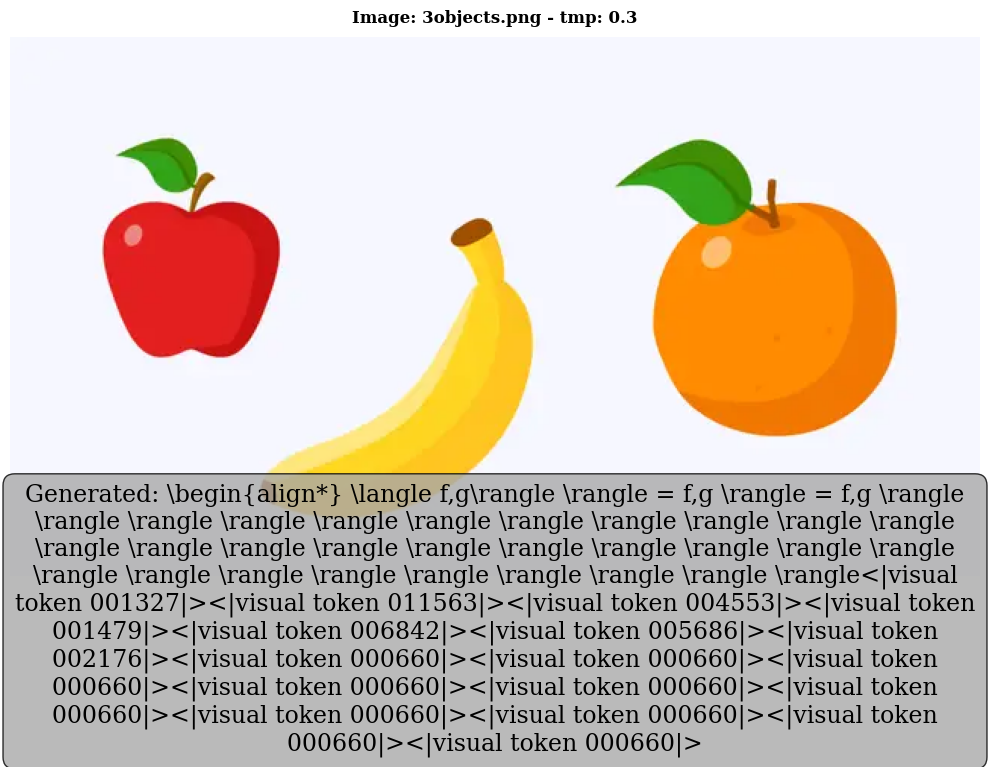


📊 Generation Statistics:
   Total tokens generated: 100
   Text tokens: 99
   Visual tokens in output: 0
   Text length: 73 words


In [40]:
GEN_TEMP = 0.3  # Generation temperature
TOP_P = 0.9  # Top-p sampling
MAX_TOKENS = 100  # Max tokens to generate
MIN_TOKENS = 5  # Minimum tokens to generate
SAVE_TO_DISK = False

# Generate text description
print("\n4. Generating text description...")
result = inferencer.generate(
    prompt,
    max_tokens=MAX_TOKENS,
    min_tokens=MIN_TOKENS,
    temperature=GEN_TEMP,  # Higher temperature for more creative text
    top_p=TOP_P,
    stop_token_ids=[inferencer.special_token_ids["end_of_turn"]]
)

# Extract text from generated tokens
print("\n5. Extracting generated text...")
generated_ids = result['generated_token_ids']
print(f"Generated token ids: {generated_ids}")

# Find where text starts (after the prompt)
text_start_idx = 0
for i, token_id in enumerate(generated_ids):
    if token_id not in inferencer.vision_mapping.values() and token_id not in inferencer.special_token_ids.values():
        text_start_idx = i
        print(f"Text starts at index {text_start_idx} (token id {token_id})")
        break

# Decode text tokens
text_ids = [tid for tid in generated_ids[text_start_idx:] 
            if tid not in inferencer.vision_mapping.values() 
            and tid not in inferencer.special_token_ids.values()]

generated_text = inferencer.tokenizer.decode(text_ids)

print("\n" + "="*80)
print("GENERATED DESCRIPTION:")
print("="*80)
print(generated_text)
print("="*80)

# Visualize image with generated caption
import matplotlib.pyplot as plt
import textwrap

fig, ax = plt.subplots(1, 1, figsize=(10, 8))

# Show the image
ax.imshow(img)
ax.axis('off')

# Add the generated text as caption
wrapped_text = textwrap.fill(f"Generated: {generated_text}", width=80)
ax.set_title(f"Image: {SELECTED_IMG.split('/')[-1]} - tmp: {GEN_TEMP}", fontsize=12, pad=10)

# Add text below the image
fig.text(0.5, 0.015, wrapped_text, ha='center', fontsize=17, 
         wrap=True, bbox=dict(boxstyle="round,pad=0.5", facecolor="darkgray", alpha=0.8))

plt.tight_layout()
plt.subplots_adjust(bottom=0.15)  # Make room for text
plt.show()

# Save
if SAVE_TO_DISK:
    save_path = f"textgen_{GEN_TEMP}tmp_{SELECTED_IMG.split('/')[-1]}"
    fig.savefig(save_path, bbox_inches='tight')
    print(f"\n💾 Saved: {save_path}")

print(f"\n📊 Generation Statistics:")
print(f"   Total tokens generated: {len(result['generated_token_ids'])}")
print(f"   Text tokens: {len(text_ids)}")
print(f"   Visual tokens in output: {result['num_visual_tokens']}")
print(f"   Text length: {len(generated_text.split())} words")